# DINOV3
- png to tensor
- handle the json data, make it usebale for linearprobe
- get the model
- feed the tensor to the model

In [ ]:
from torchvision import transforms
from PIL import Images

In [2]:
from transformers import AutoImageProcessor, AutoModel , AutoConfig

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
import matplotlib.animation as animation
from IPython.display import HTML
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity
# Third-Party (Math, ML, and Video)
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from torchvision.transforms import Resize

In [3]:
from huggingface_hub import login

In [4]:
import os

* img to tensor here->

In [9]:
# DINO expects 224x224 and specific ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Example of loading one image
img = Image.open("../svg_face_dataset/pngs/face_0000.png").convert("RGB")
input_tensor = transform(img).unsqueeze(0) # Add batch dimension [1, 3, 224, 224]
print("success")

success


In [ ]:
input_tensor

In [8]:
def var_exp(y, y_):
  tot_var = y.var() + 1e-6
  res_var = (y - y_).var()
  return 1 - res_var / tot_var

## Load the Modal

In [1]:
import sys
print(sys.executable)

/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/bin/python


In [11]:
dir(AutoModel)



['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_model_mapping',
 '_prepare_config_for_auto_class',
 'from_config',
 'from_pretrained',
 'register']

In [12]:

model_id = "facebook/dinov3-vitb16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_id)
#Pretrained
# model = AutoModel.from_pretrained(model_id)  # pre_trained

# Random model 
config = AutoConfig.from_pretrained(model_id)
model = AutoModel.from_config(config)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

png_dir = "../svg_face_dataset/pngs"
png_files = sorted([f for f in os.listdir(png_dir) if f.endswith(".png")])

all_ids = []
all_layer_cls = []

with torch.no_grad():
    for filename in tqdm(png_files):
        image_id = filename.replace(".png", "")
        img_path = os.path.join(png_dir, filename)

        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)

        outputs = model(**inputs, output_hidden_states=True)

        layer_cls = []
        for h in outputs.hidden_states:
            cls = h[:, 0, :].squeeze(0).cpu().numpy()
            layer_cls.append(cls)

        layer_cls = np.stack(layer_cls)   # [num_layers+1, hidden_dim]

        all_ids.append(image_id)
        all_layer_cls.append(layer_cls)

X_layers = np.array(all_layer_cls)

print("Done.")
print("Number of images:", len(all_ids))
print("Layerwise CLS shape:", X_layers.shape)
print("First id:", all_ids[0])

100%|██████████| 1000/1000 [01:29<00:00, 11.21it/s]

Done.
Number of images: 1000
Layerwise CLS shape: (1000, 13, 768)
First id: face_0000


In [25]:
# 1. Load the PRETRAINED model
model_id = "facebook/dinov3-vitb16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_id)
model_pretrained = AutoModel.from_pretrained(model_id) # Using .from_pretrained()

device = "cuda" if torch.cuda.is_available() else "cpu"
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

png_dir = "../svg_face_dataset/pngs"
png_files = sorted([f for f in os.listdir(png_dir) if f.endswith(".png")])

all_ids = []
all_layer_cls_pretrained = []

with torch.no_grad():
    for filename in tqdm(png_files):
        image_id = filename.replace(".png", "")
        img_path = os.path.join(png_dir, filename)

        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)

        outputs = model_pretrained(**inputs, output_hidden_states=True)

        layer_cls = []
        for h in outputs.hidden_states:
            cls = h[:, 0, :].squeeze(0).cpu().numpy()
            layer_cls.append(cls)

        all_layer_cls_pretrained.append(np.stack(layer_cls))
        all_ids.append(image_id)

X_layers_pretrained = np.array(all_layer_cls_pretrained)

# Save to a specific file for pretrained data
np.savez("dino_pretrained_out.npz", all_ids=all_ids, X_layers=X_layers_pretrained)
print("Pretrained extraction complete.")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:09<00:00, 14.47it/s]


Pretrained extraction complete.


In [13]:
file = "dino_random_out.npz" # "dino_out.npz"

np.savez(
    file,
    all_ids=all_ids,
    X_layers=X_layers
)

loaded = np.load(file)
assert np.array_equal(X_layers, loaded['X_layers'])

In [14]:
# just load
loaded = np.load(file)
X_layers = loaded['X_layers']
all_ids = loaded['all_ids']

## Here we gather the meta data for probe

In [6]:
import json 

In [15]:
meta_dir = "../svg_face_dataset/meta"

def load_meta(image_id):
    meta_path = os.path.join(meta_dir, image_id + ".json")
    with open(meta_path, "r") as f:
        return json.load(f)


In [16]:
def extract_mouth_center(meta):
    for part in meta["parts"]:
        if part["id"] == "mouth":
            return float(part["center"][0]), float(part["center"][1])

def extract_eye_features(meta):
    left_eye = None
    right_eye = None

    for part in meta["parts"]:
        if part["id"] == "eye_left":
            left_eye = {
                "center_x": float(part["center"][0]),
                "center_y": float(part["center"][1]),
                "radius": float(part["radius"])
            }
        elif part["id"] == "eye_right":
            right_eye = {
                "center_x": float(part["center"][0]),
                "center_y": float(part["center"][1]),
                "radius": float(part["radius"])
            }

    if left_eye is None:
        raise ValueError(f"No left eye found in {meta['id']}")
    if right_eye is None:
        raise ValueError(f"No right eye found in {meta['id']}")

    return {
        "left_x": left_eye["center_x"],
        "left_y": left_eye["center_y"],
        "left_radius": left_eye["radius"],
        "right_x": right_eye["center_x"],
        "right_y": right_eye["center_y"],
        "right_radius": right_eye["radius"]
    }

def extract_all_features(meta):
    features = {}
    
    for part in meta.get("parts", []):
        name = part["id"]
        # Extract common fields and handle the 'center' list specifically
        features[name] = {k: v for k, v in part.items() if k != "id"}
        
        # If you want to flatten coordinates like your original code (center_x, center_y):
        if "center" in part:
            features[name]["x"] = part["center"][0]
            features[name]["y"] = part["center"][1]
            del features[name]["center"] # Remove the list version to keep it clean

    return features


## lets look at the mouth features

In [17]:
import numpy as np

all_features = []

# New labels including RGB values
labels = [
    'face_base_x', 'face_base_y', 'face_base_radius', 
    'eye_left_x', 'eye_left_y', 'eye_left_radius',
    'eye_right_x', 'eye_right_y', 'eye_right_radius', 
    'mouth_x', 'mouth_y', 'mouth_width', 'mouth_curve',
    'skin_r', 'skin_g', 'skin_b', # New Color Features
    'eyes_r', 'eyes_g', 'eyes_b'
]

for image_id in all_ids:
    meta = load_meta(image_id)
    f = extract_all_features(meta)
    
    # Get color data (defaulting to 0 if missing)
    colors = meta.get("colors", {})
    skin_rgb = colors.get("skin", {}).get("rgb", [0, 0, 0])
    eyes_rgb = colors.get("eyes", {}).get("rgb", [0, 0, 0])
    
    # Create a flat list of exactly 19 numbers
    row = [
        f['face_base']['x'], f['face_base']['y'], f['face_base']['radius'],
        f['eye_left']['x'],  f['eye_left']['y'],  f['eye_left']['radius'],
        f['eye_right']['x'], f['eye_right']['y'], f['eye_right']['radius'],
        f['mouth']['x'],     f['mouth']['y'],     f['mouth']['width'], f['mouth']['curve'],
        # Colors
        skin_rgb[0], skin_rgb[1], skin_rgb[2],
        eyes_rgb[0], eyes_rgb[1], eyes_rgb[2]
    ]
    all_features.append(row)

# Convert to final NumPy array
feature_matrix = np.array(all_features)
print(f"New feature matrix shape: {feature_matrix.shape}") # Should be (1000, 19)

New feature matrix shape: (1000, 19)


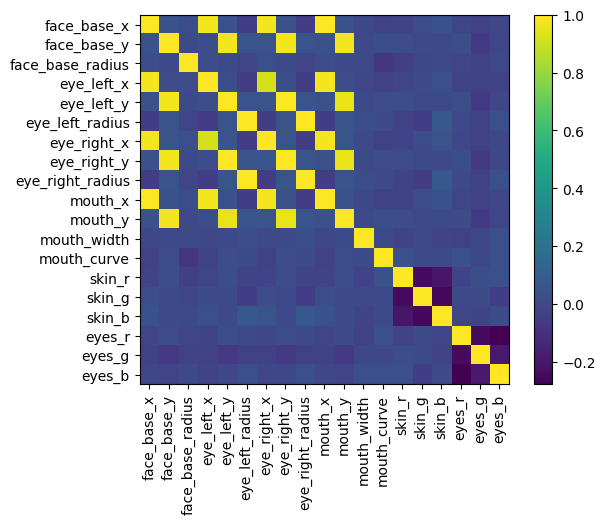

In [18]:
corr = np.corrcoef(feature_matrix, rowvar=False)
plt.imshow(corr)
# Use dynamic length for ticks
plt.yticks(np.arange(len(labels)), labels)
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.colorbar()
plt.show()

In [19]:
layer_idx = -1
X_last = X_layers[:, layer_idx, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_last, feature_matrix, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

probe = Ridge(alpha=1.0)
probe.fit(X_train, y_train)

print("Mouth X position R^2:", probe.score(X_test, y_test))



(800, 768)
(200, 768)
(800, 19)
(200, 19)
Mouth X position R^2: 0.5617302846586033


(200, 19)


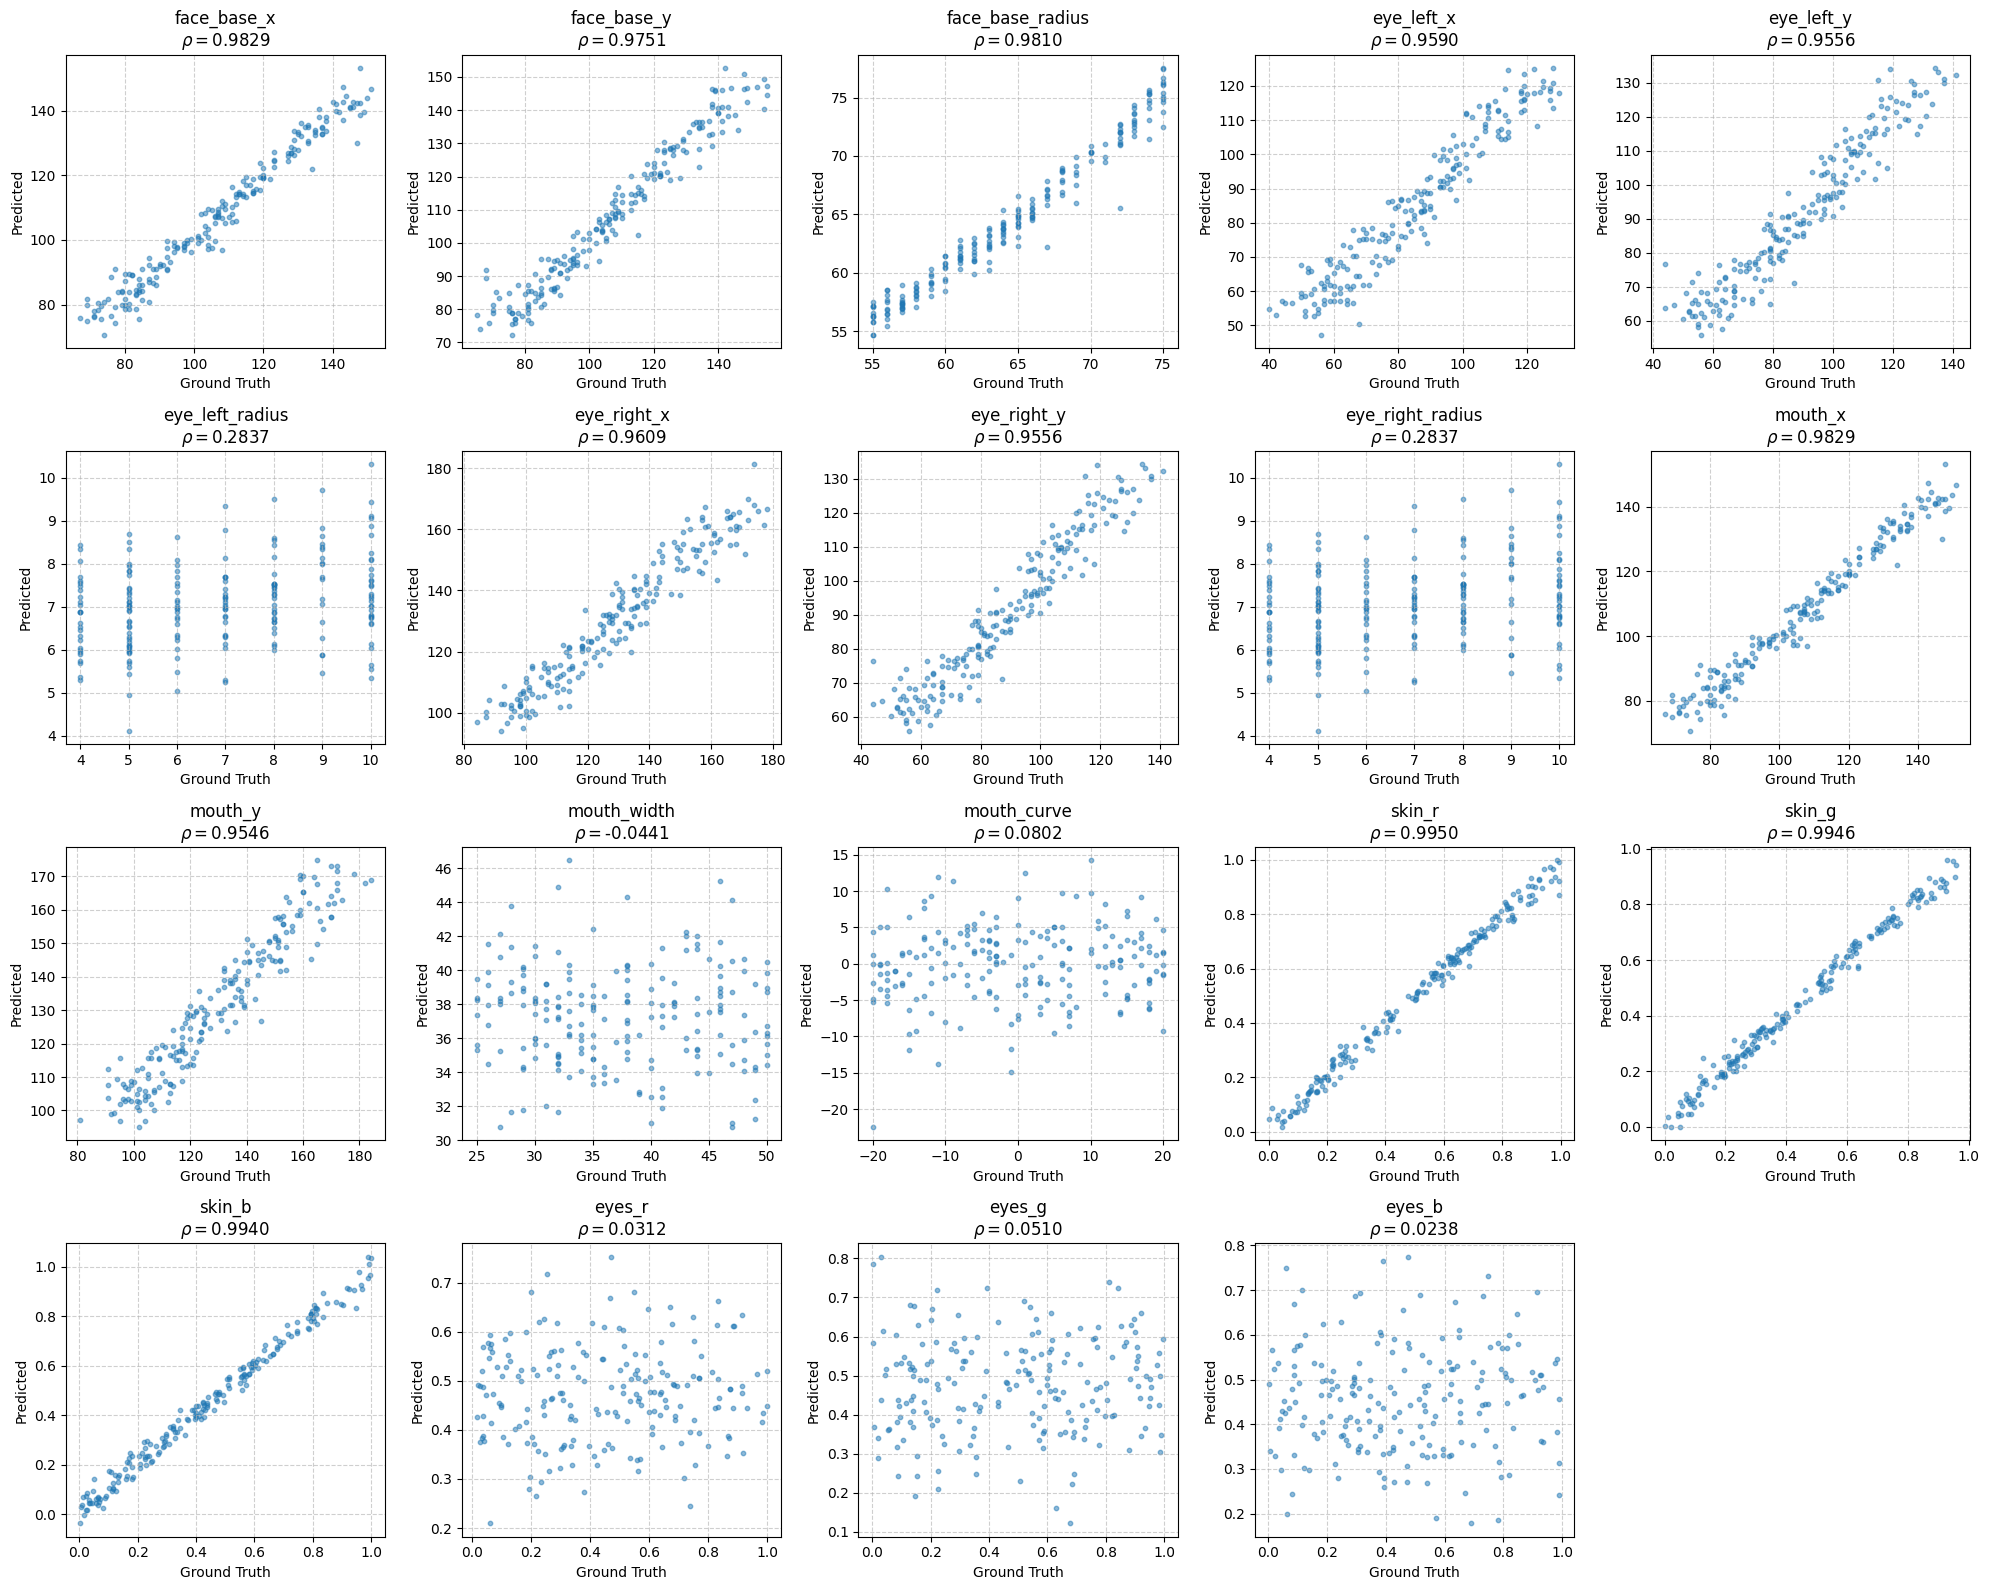

In [24]:
y_test_ = probe.predict(X_test)
print(y_test_.shape)

# 3. Plotting all 19 features
plt.figure(figsize=(20, 16)) # Increased size for 19 plots

for i in range(len(labels)):
    plt.subplot(4, 5, i + 1) # 4 rows, 5 columns = 20 slots
    
    # Actual vs Predicted
    plt.scatter(y_test[:, i], y_test_[:, i], alpha=0.5, s=10)
    
    # Calculate correlation
    r, _ = pearsonr(y_test[:, i], y_test_[:, i])
    
    plt.title(f'{labels[i]}\n' + r'$\rho=$' + f'{r:.4f}')
    plt.xlabel('Ground Truth')
    plt.ylabel('Predicted')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("prediction_accuracy_all.png")

In [18]:
# 1. Prepare to store correlations for all layers
num_layers = X_layers.shape[1] # DINOv3 has 13 hidden states (0 to 12)
all_layer_rhos = np.zeros((num_layers, 13)) # Array to hold (13 layers x 13 features)

print(f"Processing {num_layers} layers...")

# 2. Loop through every layer to train and test
for layer_idx in range(num_layers):
    X_curr = X_layers[:, layer_idx, :]
    
    # Use your exact split logic
    X_train, X_test, y_train, y_test = train_test_split(
        X_curr, feature_matrix, test_size=0.2, random_state=42
    )
    
    # Train the probe for this specific layer
    probe = Ridge(alpha=1.0)
    probe.fit(X_train, y_train)
    y_test_pred = probe.predict(X_test)
    
    # Calculate Pearson Rho for all 13 features at this layer
    for i in range(13):
        rho, _ = pearsonr(y_test[:, i], y_test_pred[:, i])
        all_layer_rhos[layer_idx, i] = rho


Processing 13 layers...


/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.32404e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [26]:
def get_layer_accuracy(X_layers, y_matrix):
    num_layers = X_layers.shape[1]
    num_features = y_matrix.shape[1]
    rhos = np.zeros((num_layers, num_features))
    
    for l in range(num_layers):
        X_curr = X_layers[:, l, :]
        X_tr, X_te, y_tr, y_te = train_test_split(X_curr, y_matrix, test_size=0.2, random_state=42)
        
        probe = Ridge(alpha=1.0)
        probe.fit(X_tr, y_tr)
        y_pred = probe.predict(X_te)
        
        for i in range(num_features):
            rho, _ = pearsonr(y_te[:, i], y_pred[:, i])
            rhos[l, i] = rho
    return rhos

# Assuming X_layers (random) is already loaded from your previous cell
rhos_random = get_layer_accuracy(X_layers, feature_matrix)
rhos_pretrained = get_layer_accuracy(X_layers_pretrained, feature_matrix)

/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.32404e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


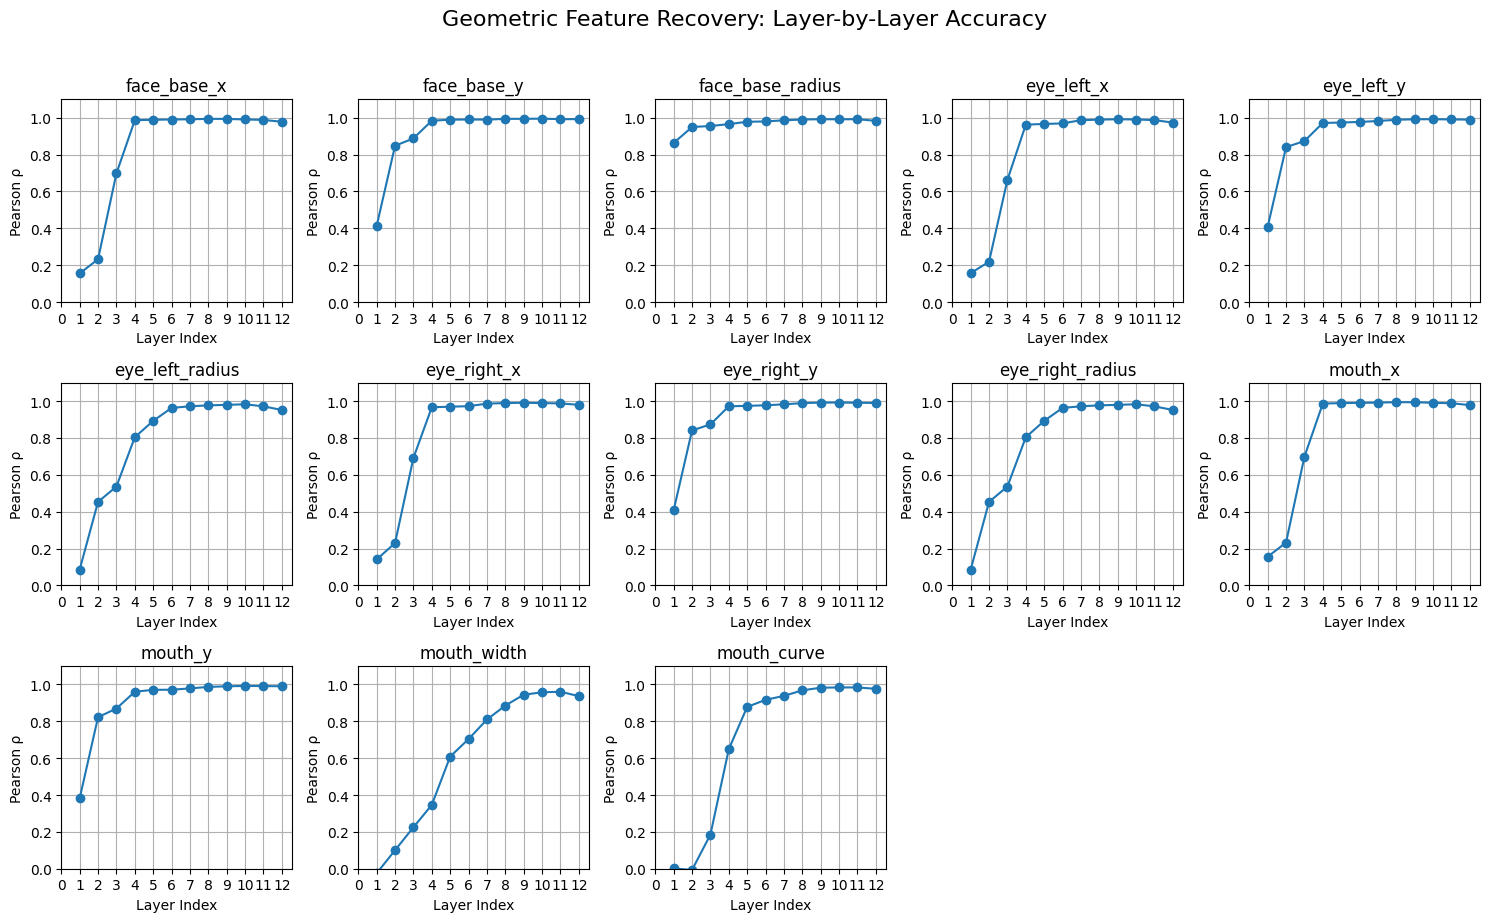

In [19]:
# 3. Plotting the results in your 3x5 grid format
plt.figure(figsize=(15, 9))
layers = np.arange(num_layers) # This is [0, 1, 2, ..., 12]

for i in range(13):
    plt.subplot(3, 5, i + 1)
    
    # Plot Layer Index vs. Prediction Accuracy (Rho)
    plt.plot(layers, all_layer_rhos[:, i], marker='o', linestyle='-', color='tab:blue')
    plt.xticks(layers) 
    plt.title(f"{labels[i]}")
    plt.xlabel("Layer Index")
    plt.ylabel("Pearson ρ") # Updated this to match what you are actually plotting!
    plt.ylim(0, 1.1) 
    plt.grid(True)

plt.suptitle("Geometric Feature Recovery: Layer-by-Layer Accuracy", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

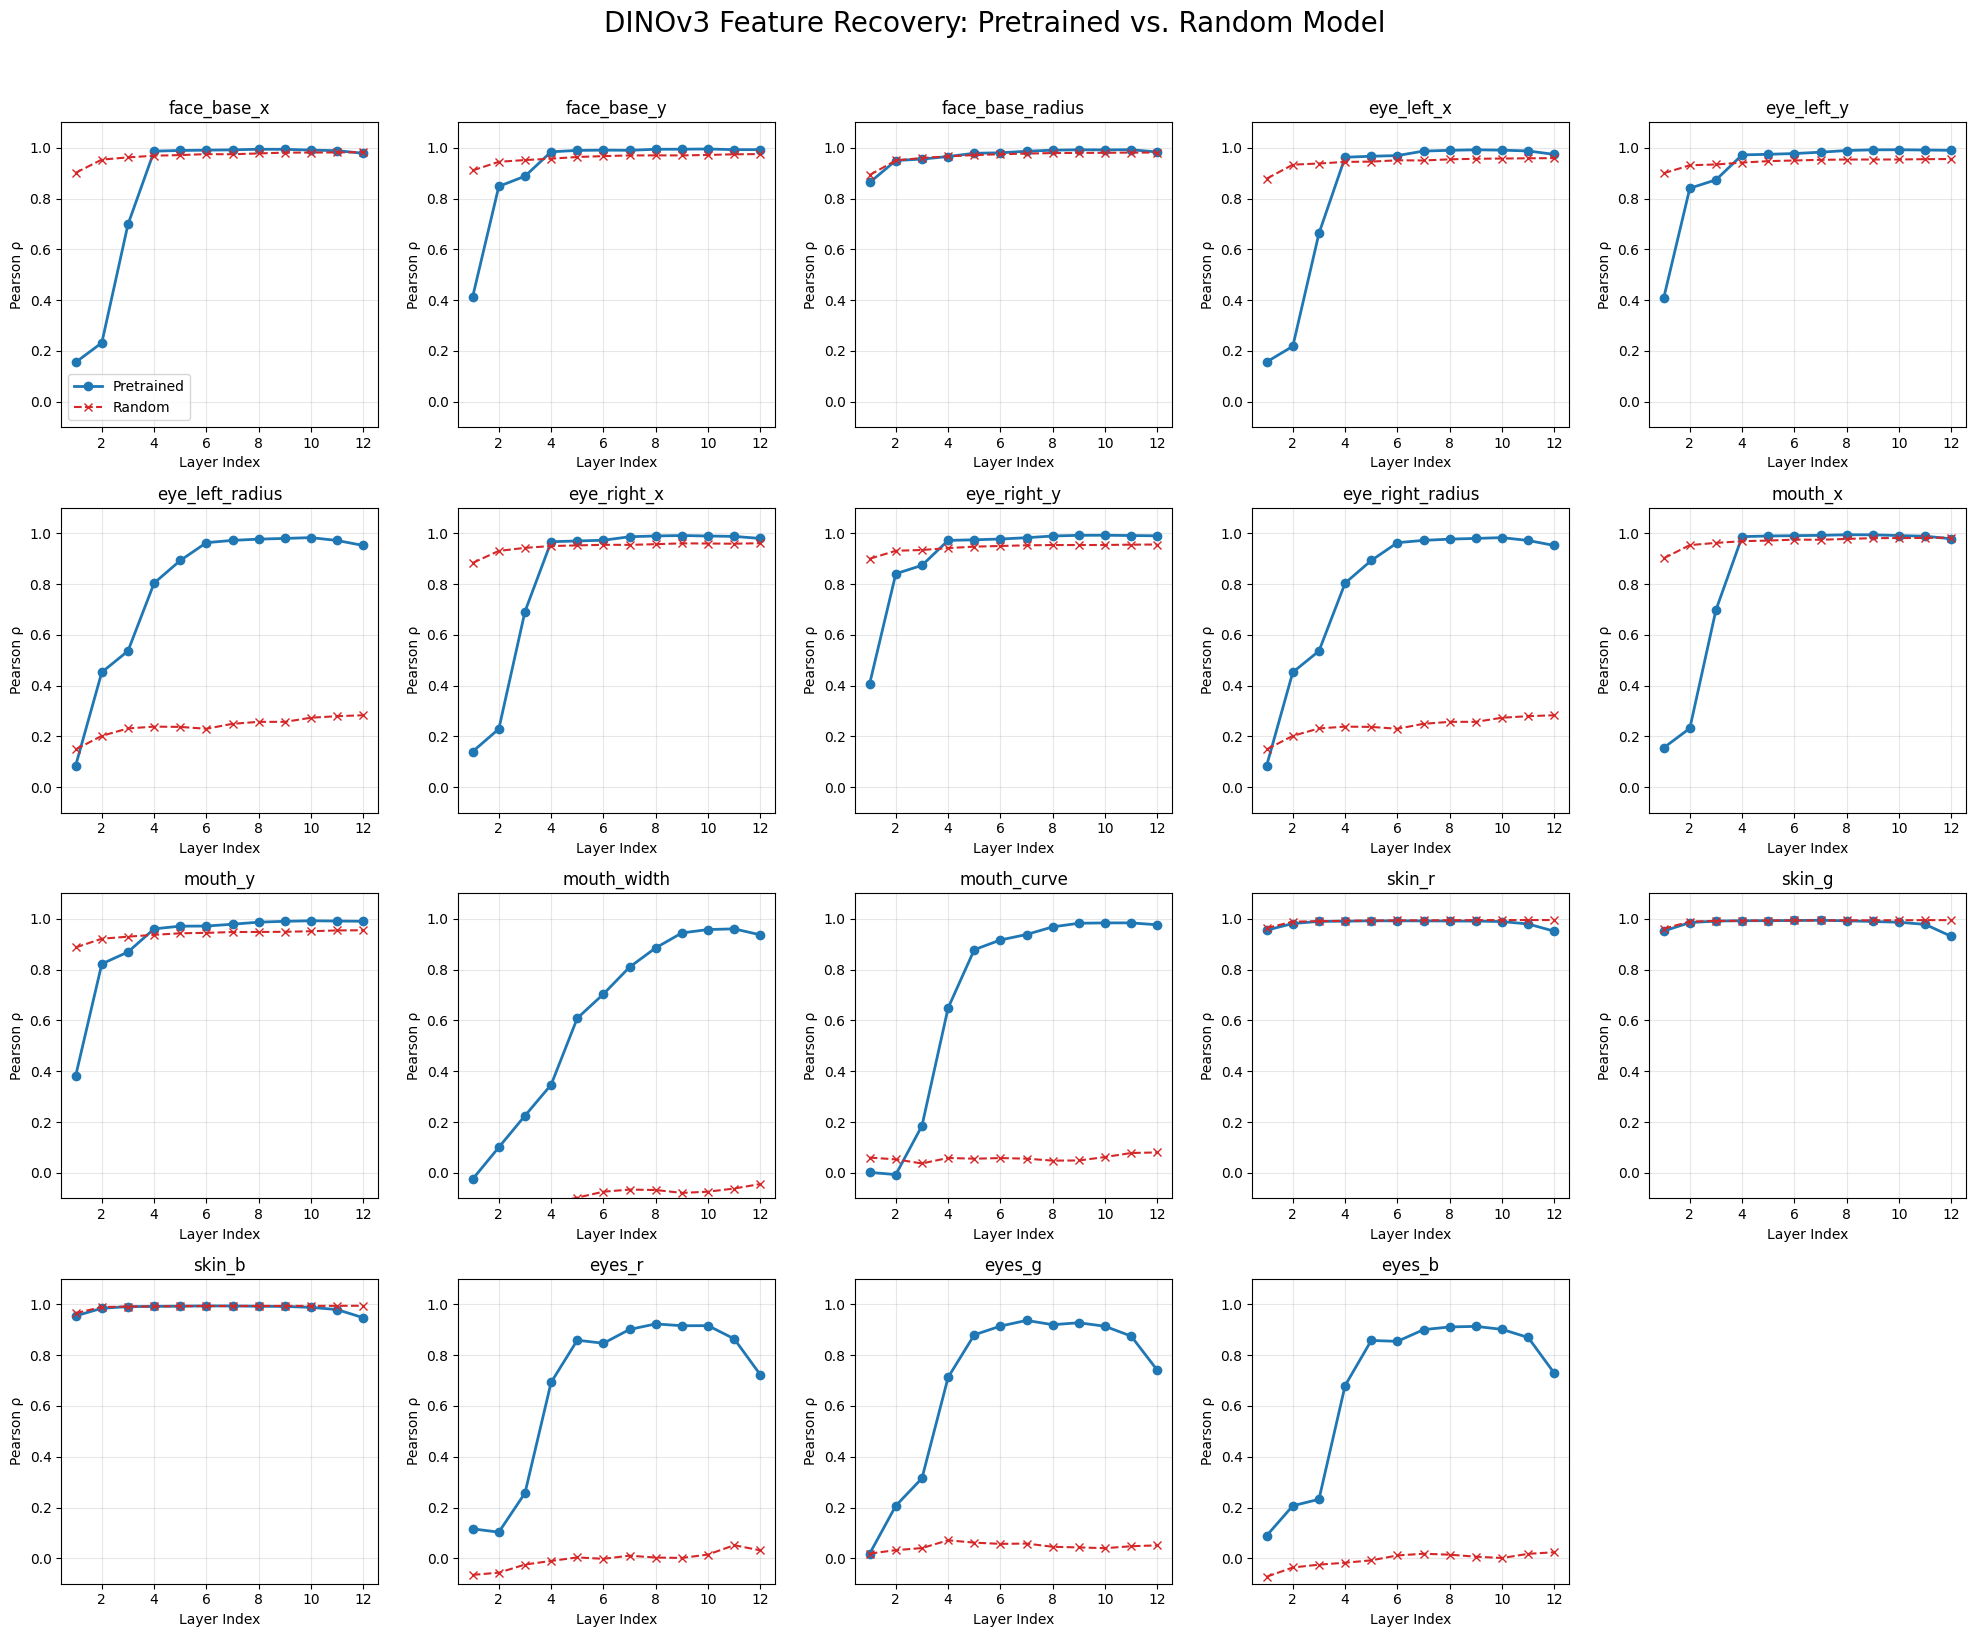

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
layers = np.arange(rhos_random.shape[0])

for i in range(len(labels)):
    plt.subplot(4, 5, i + 1)
    
    # Pretrained Line
    plt.plot(layers, rhos_pretrained[:, i], marker='o', label='Pretrained', color='tab:blue', linewidth=2)
    # Random Line
    plt.plot(layers, rhos_random[:, i], marker='x', label='Random', color='tab:red', linestyle='--')
    
    plt.title(f"{labels[i]}")
    plt.xlabel("Layer Index")
    plt.ylabel("Pearson ρ")
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.3)
    if i == 0: plt.legend()

plt.suptitle("DINOv3 Feature Recovery: Pretrained vs. Random Model", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("pretrained_vs_random_comparison.png")

## Try to redraw SVG from any PNG

In [26]:
from sklearn.decomposition import PCA
import pandas as pd

# 1. Ask PCA to find the top 13 patterns (Principal Components)
pca = PCA(n_components=13)
X_pca = pca.fit_transform(X_last) 

results = []

# 2. Loop through each pattern and find its "Best Friend" in your labels
for i in range(13):
    correlations = []
    for j in range(13):
        # We use absolute value because -0.9 is just as strong as +0.9
        rho, _ = pearsonr(X_pca[:, i], feature_matrix[:, j])
        correlations.append(abs(rho))
    
    # Find which of your labels matches this DINO pattern best
    best_idx = np.argmax(correlations)
    best_label = labels[best_idx]
    best_score = correlations[best_idx]
    
    results.append({
        "DINO Pattern": f"#{i}",
        "Top Match": best_label,
        "Clarity Score (ρ)": f"{best_score:.4f}"
    })

# 3. Display as a clean list
print(f"{'DINO Discovery':<15} | {'Your SVG Label':<18} | {'Strength'}")
print("-" * 50)
for r in results:
    print(f"{r['DINO Pattern']:<15} | {r['Top Match']:<18} | {r['Clarity Score (ρ)']}")

DINO Discovery  | Your SVG Label     | Strength
--------------------------------------------------
#0              | mouth_curve        | 0.9286
#1              | mouth_width        | 0.1709
#2              | mouth_width        | 0.3141
#3              | eye_left_radius    | 0.7305
#4              | eye_left_radius    | 0.2627
#5              | face_base_radius   | 0.6471
#6              | mouth_width        | 0.1790
#7              | mouth_width        | 0.3369
#8              | mouth_width        | 0.1918
#9              | mouth_width        | 0.1998
#10             | mouth_width        | 0.3491
#11             | mouth_y            | 0.1778
#12             | face_base_radius   | 0.2988


In [24]:
from transformers import AutoImageProcessor, AutoModel
import torch

# 1. Setup the "Brain" and the "Eyes"
model_id = "facebook/dinov3-vitb16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# This is the 'processor' that was missing—it resizes the image for DINO
processor = AutoImageProcessor.from_pretrained(model_id)
# This is the 'model'—the actual DINOv3 transformer
model = AutoModel.from_pretrained(model_id).to(device)
model.eval()

print(f"Model and processor loaded on {device}!")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model and processor loaded on cuda!


In [27]:
def svg_ify_real_face(image_path):
    # 1. Load the real image
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(images=raw_image, return_tensors="pt").to(device)

    # 2. Get the DINOv3 "Brain State" (Layer 12)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Get the CLS token from the last layer
        features = outputs.hidden_states[-1][:, 0, :].cpu().numpy()

    # 3. Use your trained probes to "predict" the SVG values for YOUR face
    # (Assuming you have a 'probe' object that predicts all 13 features)
    preds = probe.predict(features)[0]

    # 4. Map the predictions to a dictionary
    face_data = {labels[i]: preds[i] for i in range(13)}

    # 5. Display the predicted coordinates
    print(f"DINO's analysis of your face:")
    print(f"- Mouth Curve: {face_data['mouth_curve']:.2f}")
    print(f"- Face Position: ({face_data['face_base_x']:.1f}, {face_data['face_base_y']:.1f})")

    # 6. Redraw using your SVG tools
    # This will create a 'geometric ghost' of your face!
    return face_data

test_face = svg_ify_real_face("guy_face.png")

DINO's analysis of your face:
- Mouth Curve: 81.77
- Face Position: (65.0, 171.6)


In [80]:
import torch
import numpy as np
from PIL import Image
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from IPython.display import SVG, display

# 1. ENSURE PROBE IS TRAINED (Last Layer)
# We use all 13 features at once (feature_matrix)
X_last = X_layers[:, -1, :] 
X_train, X_test, y_train, y_test = train_test_split(
    X_last, feature_matrix, test_size=0.2, random_state=42
)
probe = Ridge(alpha=1.0)
probe.fit(X_train, y_train)

# 1. Pre-calculate the mean/std for denormalization
feature_means = feature_matrix.mean(axis=0)
feature_stds = feature_matrix.std(axis=0)

def generate_svg_simple(preds, labels_list):
    d = {labels_list[i]: preds[i] for i in range(13)}
    # Calculate Mouth Path
    x_left = d['mouth_x'] - (d['mouth_width'] / 2)
    x_right = d['mouth_x'] + (d['mouth_width'] / 2)
    mouth_path = f"M {x_left},{d['mouth_y']} Q {d['mouth_x']},{d['mouth_y'] + d['mouth_curve']} {x_right},{d['mouth_y']}"

    # The SVG: 400x400 display, but 200x200 coordinate space
    svg_template = f"""
    <svg width="200" height="200" viewBox="0 0 200 200" xmlns="http://www.w3.org/2000/svg">
        <rect width="100%" height="100%" fill="#fdfdfd" stroke="#ccc" />
        <circle cx="{d['face_base_x']}" cy="{d['face_base_y']}" r="{d['face_base_radius']}" fill="none" stroke="black" stroke-width="1.5" />
        <circle cx="{d['eye_left_x']}" cy="{d['eye_left_y']}" r="{d['eye_left_radius']}" fill="black" />
        <circle cx="{d['eye_right_x']}" cy="{d['eye_right_y']}" r="{d['eye_right_radius']}" fill="black" />
        <path d="{mouth_path}" stroke="black" stroke-width="2" fill="none" stroke-linecap="round" />
    </svg>
    """
    return svg_template

def run_svg_pipeline(image_path):
    # 1. Standard processing
    raw_img = Image.open(image_path).convert("RGB")
    img_200 = raw_img.resize((200, 200))
    
    inputs = processor(images=img_200, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=True)
        features = out.hidden_states[-1][:, 0, :].cpu().numpy()

    # 2. JUST THE PROBE VALUES (No mean/std math)
    # This takes the raw output of the Ridge model
    raw_preds = probe.predict(features)[0]
    
    # 3. Render
    svg_code = generate_svg_simple(raw_preds, labels)
    
    print(f"--- Raw Probe Prediction: {image_path} ---")
    display(img_200)
    display(SVG(svg_code))
    
    return raw_preds


/grid/it/data/elzar/easybuild/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.32404e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


--- Raw Probe Prediction: smiling-face.png ---


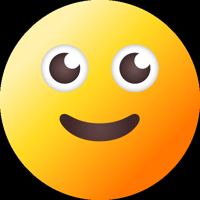

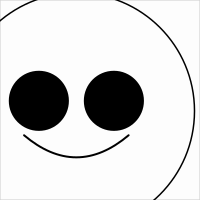

In [81]:
results = run_svg_pipeline("smiling-face.png")

--- Raw Probe Prediction: sad-face.png ---


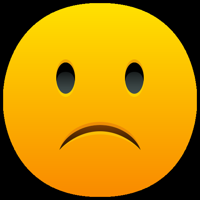

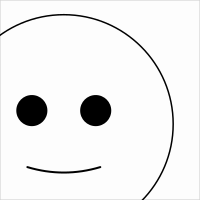

In [82]:
results = run_svg_pipeline("sad-face.png")

--- Raw Probe Prediction: really-sad-face.png ---


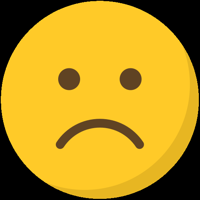

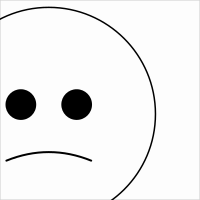

In [86]:
results = run_svg_pipeline("really-sad-face.png")

--- Raw Probe Prediction: bad-face.png ---


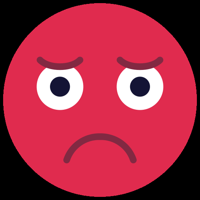

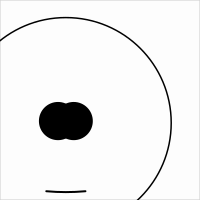

In [84]:
results = run_svg_pipeline("bad-face.png")

--- Raw Probe Prediction: another-bad-face.png ---


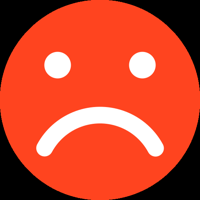

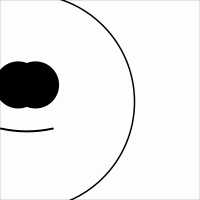

In [85]:
results = run_svg_pipeline("another-bad-face.png")

--- Raw Probe Prediction: sad.png ---


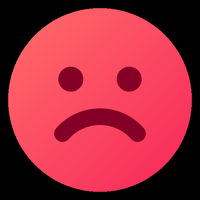

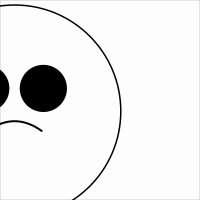

In [87]:
results = run_svg_pipeline("sad.png")